In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from rapidfuzz.distance import Jaro, JaroWinkler

In [2]:
pacientes=pd.read_csv('pacientes_clinica.csv')
pacientes

,id_paciente,edad,imc,glucosa,actividad_fisica,tabaquismo,presion_sistolica
0,CL-0824,55,29.3,106.0,0,1,150.7
1,RM-0657,51,27.3,84.9,1,1,147.8
2,HC-0097,73,26.9,75.3,1,0,138.4
3,HC-3063,72,27.0,97.6,0,0,141.9
4,PA-5689,32,19.8,95.4,1,0,124.1
...,...,...,...,...,...,...,...
179,HC-6890,65,35.4,65.4,0,0,145.4
180,PA-6918,55,28.2,114.2,1,1,150.9
181,HC-8286,42,25.6,132.7,0,0,127.3
182,HC-0108,56,27.9,113.9,1,0,141.8


In [3]:
pacientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_paciente        184 non-null    object 
 1   edad               184 non-null    int64  
 2   imc                184 non-null    float64
 3   glucosa            184 non-null    float64
 4   actividad_fisica   184 non-null    int64  
 5   tabaquismo         184 non-null    int64  
 6   presion_sistolica  184 non-null    float64
dtypes: float64(3), int64(3), object(1)
memory usage: 10.2+ KB


In [4]:
pacientes.drop_duplicates()

,id_paciente,edad,imc,glucosa,actividad_fisica,tabaquismo,presion_sistolica
0,CL-0824,55,29.3,106.0,0,1,150.7
1,RM-0657,51,27.3,84.9,1,1,147.8
2,HC-0097,73,26.9,75.3,1,0,138.4
3,HC-3063,72,27.0,97.6,0,0,141.9
4,PA-5689,32,19.8,95.4,1,0,124.1
...,...,...,...,...,...,...,...
179,HC-6890,65,35.4,65.4,0,0,145.4
180,PA-6918,55,28.2,114.2,1,1,150.9
181,HC-8286,42,25.6,132.7,0,0,127.3
182,HC-0108,56,27.9,113.9,1,0,141.8


In [5]:
pacientes['tabaquismo'].value_counts(normalize=True)

tabaquismo
0    0.690217
1    0.309783
Name: proportion, dtype: float64

C:\Users\maxim\AppData\Local\Temp\ipykernel_6080\732773009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pacientes,x='tabaquismo',stat='percent',palette='Set1')


Text(0.5, 0, 'Fumadora?')

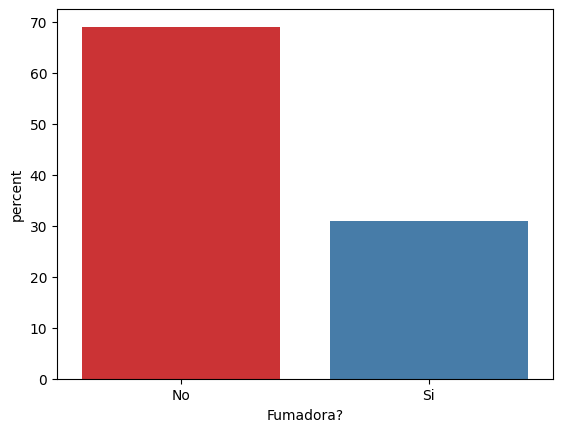

In [6]:
#Ejercicio 2a grafico
sns.countplot(data=pacientes,x='tabaquismo',stat='percent',palette='Set1')
plt.xticks(ticks = range(2),labels = ['No', 'Si'])
plt.xlabel('Fumadora?')


* Se puede observar que el porcentaje de no fumadores es de casi 70%, para ser mas exactos 69%. Mas del doble de fumadores

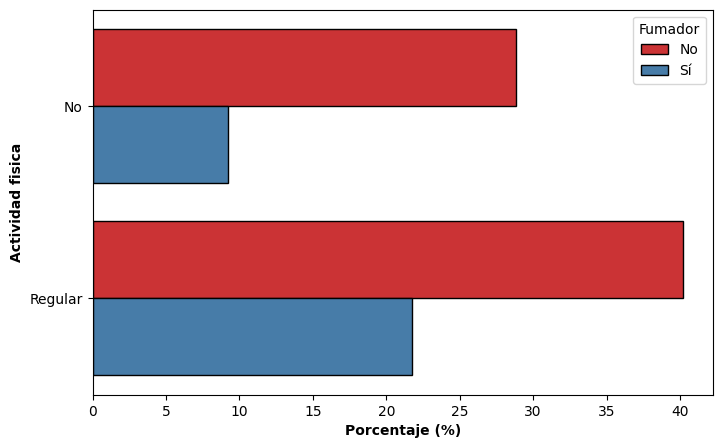

In [7]:
#Ejercicio 2b grafico
plt.figure(figsize = (8, 5))

sns.countplot(y = 'actividad_fisica', hue = 'tabaquismo', stat = 'percent',palette = 'Set1', edgecolor = 'black', data = pacientes)

plt.xlabel('Porcentaje (%)', fontweight = 'bold')
plt.ylabel('Actividad fisica', fontweight = 'bold')
plt.yticks(ticks = range(2),labels = ['No', 'Regular'])

plt.legend(title = 'Fumador', labels = ['No', 'Sí'],
facecolor = 'white')

plt.show()

In [8]:
pacientes.groupby('tabaquismo')['actividad_fisica'].value_counts()



tabaquismo  actividad_fisica
0           1                   74
            0                   53
1           1                   40
            0                   17
Name: count, dtype: int64

In [9]:
print(f'Realizan actividad fisica regularmente sin fumar un {round(74*100/len(pacientes),2)} % de los pacientes')

Realizan actividad fisica regularmente sin fumar un 40.22 % de los pacientes


# Ejercicio 3

In [20]:
# Similaridad de Jaro para Candidato A CL-0A81
simA1 = round(JaroWinkler.similarity('CL-0A81', 'CL-0481'), 4)
print(simA1)

0.9429


In [21]:
# Similaridad de Jaro para Candidato B CL-0A81
simB1 = round(JaroWinkler.similarity('CL-0A81', 'CL-0824'), 4)
print(simB1)

0.8857


In [22]:
# Similaridad de Jaro para Candidato A CI-1B27
simA2 = round(JaroWinkler.similarity('CI-1B27', 'CL-1327'), 4)
print(simA2)

0.8286


In [23]:
# Similaridad de Jaro para Candidato B CI-1B27
simB2 = round(JaroWinkler.similarity('CI-1B27', 'CL-2137'), 4)
print(simB2)

0.7686


* Para el ID CL-0A81 es mejor candidato el A CL-0481. Y para el ID CI-1B27 ninguno de los dos supera el umbral de 0.90

# Ejercicio 4

In [14]:
pacientes.columns.tolist()

['id_paciente',
 'edad',
 'imc',
 'glucosa',
 'actividad_fisica',
 'tabaquismo',
 'presion_sistolica']

In [15]:
modelo=smf.ols(' presion_sistolica ~ edad + imc + glucosa + actividad_fisica + tabaquismo', data=pacientes).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:      presion_sistolica   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     109.0
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           2.85e-52
Time:                        19:20:44   Log-Likelihood:                -598.64
No. Observations:                 184   AIC:                             1209.
Df Residuals:                     178   BIC:                             1229.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           49.9685      4.225  

* Se observa que el p-valor de actividad fisica es mayor al 0.05 entonces puede no ser significativa y descartarse como variable predictora

Procedo con un nuevo modelo sin esta variable de actividad fisica 

In [16]:
#4b
modelo2=smf.ols(' presion_sistolica ~ edad + imc + glucosa + tabaquismo', data=pacientes).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:      presion_sistolica   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     136.8
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           2.57e-53
Time:                        19:20:44   Log-Likelihood:                -598.77
No. Observations:                 184   AIC:                             1208.
Df Residuals:                     179   BIC:                             1224.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.8068      4.203     11.851      0.0

* Este modelo tiene un $R^2_{adj}=0.748$ que es apenas mayor al del modelo1 de $R^2_{adj}=0.747$ no se nota gran diferencia entre modelos, podria usar cualquiera para predecir

* Me quedo con el modelo2 y su ecuacion lineal multiple es:
  
  $\hat{y}=49.8068+0.5191*x_{edad}+1.3770*x_{imc}+0.2124*x_{glucosa}+7.0325*x_{fumador}$

In [17]:
#4d
prediccion=49.8068+0.5191*50+1.3770*28.5+0.2124*102+7.0325*0
print(f'La presion sistolica de una paciente de 50 años, no fumadora, glucemia de 102 mg/dL e IMC de 28.5kg/m2 es {prediccion:.2f} mmHg')

La presion sistolica de una paciente de 50 años, no fumadora, glucemia de 102 mg/dL e IMC de 28.5kg/m2 es 136.67 mmHg


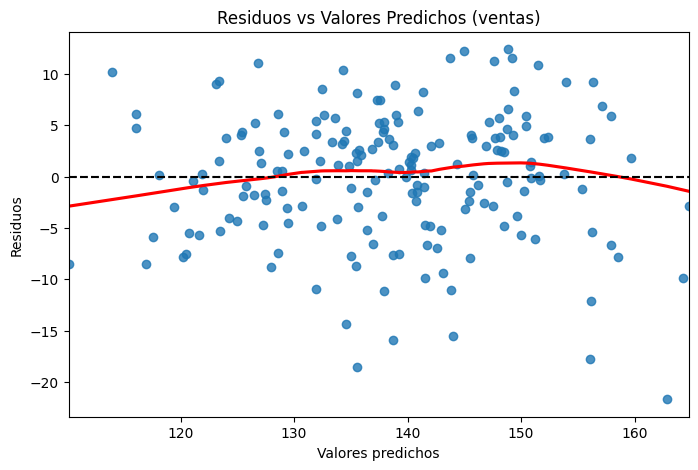

In [18]:
#4e
plt.figure(figsize=(8,5))
sns.residplot(x=modelo2.fittedvalues, y=modelo2.resid, lowess=True, line_kws={'color': 'red'})
plt.title("Residuos vs Valores Predichos (ventas)")
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.show()

* No se observa un patron de embudo pero tampoco un patron lineal cercano a la linea de cero. Se observa un patron algo curvilineo con forma de 'm' que se aleja en las puntas, es probable que el modelo lineal este mal especificado

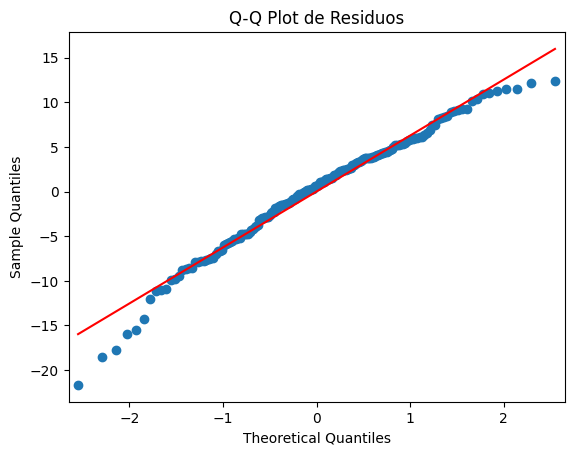

In [19]:
# Normalidad de Residuos
sm.qqplot(modelo2.resid, line='s')
plt.title("Q-Q Plot de Residuos")
plt.show()

* Se observa como en el centro si se encuentran sobre la diagonal pero a medida que nos acercamos a los extremos se curvan y se alejan de la diagonal lo que puede indicar que los datos tienen colas mas pesadas o ligeras que una distribucion normal